## 1. Setup

In [1]:
import os, re, random, math, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, StratifiedGroupKFold,
    GroupShuffleSplit,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)

warnings.filterwarnings("ignore")
print("PyTorch:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch: 2.5.1+cu121
Device: cuda


## 2. Configuration

In [2]:
CONFIG = {
    
     "DATA_DIR": r"C:\Users\c8472912\Desktop\D\paper\digits\final\paper\dataset",
    "CSV_PATH": None,          
    "LABEL_COLUMN": "label",  

    
    "IMAGE_SIZE": 16,
    "N_CLASSES": 10,

    
    "TEST_FRACTION": 0.20,     # size of the frozen held-out test set
    "N_FOLDS": 5,              # k in k-fold cross-validation (on the dev set)
    "SEEDS": [0, 1, 2],        # repeat CV with several seeds for mean +/- std

    # ---- Writer information ----
    "WRITER_ID_REGEX": r"^(aila|alireza|reyhane|dj|sa|ma|m|n)\b",
    "USE_WRITER_DISJOINT": True,

    # ---- CNN hyperparameters ----
    "EPOCHS": 60,
    "BATCH_SIZE": 64,
    "LR": 1e-3,
    "WEIGHT_DECAY": 1e-4,
    "EARLY_STOP_PATIENCE": 10, 
    "DROPOUT": 0.3,
    "USE_AUGMENTATION": True,  # light random shifts on TRAIN images only
    "AUG_MAX_SHIFT": 2,        # max pixel shift for augmentation
}
CONFIG

{'DATA_DIR': 'C:\\Users\\c8472912\\Desktop\\D\\paper\\digits\\final\\paper\\dataset',
 'CSV_PATH': None,
 'LABEL_COLUMN': 'label',
 'IMAGE_SIZE': 16,
 'N_CLASSES': 10,
 'TEST_FRACTION': 0.2,
 'N_FOLDS': 5,
 'SEEDS': [0, 1, 2],
 'WRITER_ID_REGEX': '^(aila|alireza|reyhane|dj|sa|ma|m|n)\\b',
 'USE_WRITER_DISJOINT': False,
 'EPOCHS': 60,
 'BATCH_SIZE': 64,
 'LR': 0.001,
 'WEIGHT_DECAY': 0.0001,
 'EARLY_STOP_PATIENCE': 10,
 'DROPOUT': 0.3,
 'USE_AUGMENTATION': True,
 'AUG_MAX_SHIFT': 2}

## 3. Reproducibility


In [20]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["SEEDS"][0])

## 4. Load the data

Returns:
- `X` — float32 array, shape `(N, 1, H, W)`, pixel values scaled to `[0, 1]` (a fixed transform, so no leakage);
- `y` — integer labels `0..9`;
- `groups` — writer id per sample, or `None` if not available.


In [4]:
def _writer_from_name(fname, pattern):
    if pattern is None:
        return None
    m = re.match(pattern, fname, flags=re.IGNORECASE)
    return m.group(1).lower() if m else None


def load_from_image_folders(data_dir, image_size, writer_regex=None):
    from PIL import Image
    data_dir = Path(data_dir)
    X, y, writers = [], [], []
    class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()],
                         key=lambda s: (len(s), s))
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".pgm"}
    for label_idx, cname in enumerate(class_names):
        for fp in sorted((data_dir / cname).iterdir()):
            if fp.suffix.lower() not in exts:
                continue
            img = Image.open(fp).convert("L").resize((image_size, image_size))
            X.append(np.asarray(img, dtype=np.float32))
            y.append(int(cname) if cname.lstrip("-").isdigit() else label_idx)
            writers.append(_writer_from_name(fp.name, writer_regex))
    X = np.stack(X)[:, None, :, :] / 255.0            # (N,1,H,W) in [0,1]
    y = np.asarray(y, dtype=np.int64)
    
    groups = None
    if writer_regex is not None and any(w is not None for w in writers):
        groups = np.array([w if w is not None else f"__unknown_{i}"
                           for i, w in enumerate(writers)], dtype=object)
    return X, y, groups


def load_from_csv(csv_path, label_col, image_size):
    df = pd.read_csv(csv_path)
    y = df[label_col].to_numpy(dtype=np.int64)
    pixels = df.drop(columns=[label_col]).to_numpy(dtype=np.float32)
    n_px = image_size * image_size
    assert pixels.shape[1] == n_px, (
        f"CSV has {pixels.shape[1]} pixel columns but IMAGE_SIZE={image_size} "
        f"expects {n_px}. Fix IMAGE_SIZE.")
    X = pixels.reshape(-1, 1, image_size, image_size)
    if X.max() > 1.5:            # values look like 0..255
        X = X / 255.0
    return X, y, None


if CONFIG["CSV_PATH"]:
    X, y, groups = load_from_csv(CONFIG["CSV_PATH"], CONFIG["LABEL_COLUMN"], CONFIG["IMAGE_SIZE"])
else:
    X, y, groups = load_from_image_folders(CONFIG["DATA_DIR"], CONFIG["IMAGE_SIZE"],
                                           CONFIG["WRITER_ID_REGEX"])

print("X shape:", X.shape, "| y shape:", y.shape)
print("Samples per class:", dict(sorted(Counter(y.tolist()).items())))
if groups is not None:
    named = [g for g in groups if not str(g).startswith("__unknown_")]
    print("Named writers:", dict(sorted(Counter(named).items())))
    print(f"Files with a known writer: {len(named)} / {len(y)} "
          f"({100*len(named)/len(y):.0f}%); the rest are unknown-writer.")


USE_GROUPS = bool(CONFIG["USE_WRITER_DISJOINT"]) and groups is not None
print("Splitting mode:", "WRITER-DISJOINT" if USE_GROUPS else "stratified by class")

X shape: (2560, 1, 16, 16) | y shape: (2560,)
Samples per class: {0: 187, 1: 196, 2: 533, 3: 533, 4: 192, 5: 187, 6: 187, 7: 182, 8: 182, 9: 181}
Named writers: {'aila': 319, 'alireza': 300, 'dj': 310, 'm': 16, 'ma': 314, 'n': 300, 'reyhane': 300, 'sa': 299}
Files with a known writer: 2158 / 2560 (84%); the rest are unknown-writer.
Splitting mode: stratified by class


### Class balance


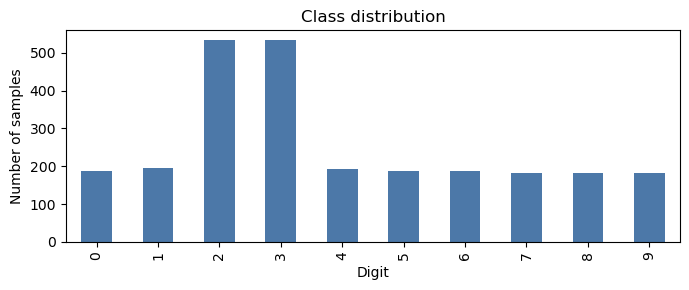

Imbalance ratio (max/min): 2.94


In [5]:
counts = pd.Series(Counter(y.tolist())).sort_index()
ax = counts.plot(kind="bar", figsize=(7,3), color="#4C78A8")
ax.set_xlabel("Digit"); ax.set_ylabel("Number of samples"); ax.set_title("Class distribution")
plt.tight_layout(); plt.show()
print("Imbalance ratio (max/min):", round(counts.max()/counts.min(), 2))

### A few example images

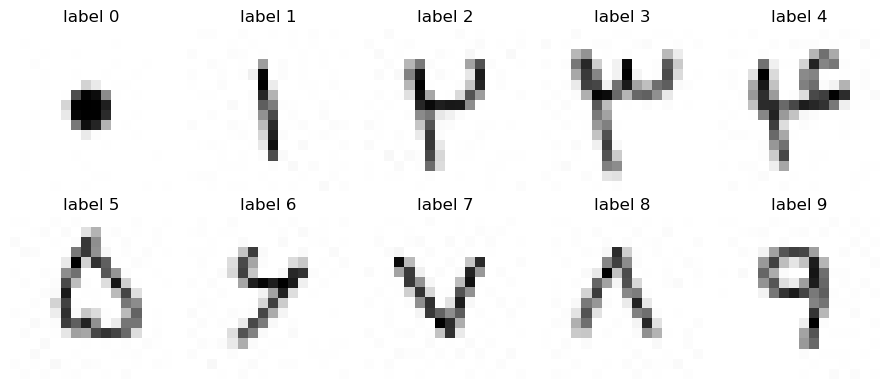

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for d in range(10):
    idx = np.where(y == d)[0]
    ax = axes[d // 5][d % 5]
    if len(idx):
        ax.imshow(X[idx[0], 0], cmap="gray"); ax.set_title(f"label {d}")
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Freeze the held-out test set (once)

In [7]:
def make_frozen_test_split(X, y, groups, test_fraction, seed):
    if groups is not None:
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_fraction, random_state=seed)
        dev_idx, test_idx = next(splitter.split(X, y, groups))
    else:
        dev_idx, test_idx = train_test_split(
            np.arange(len(y)), test_size=test_fraction, stratify=y, random_state=seed)
    return dev_idx, test_idx


split_groups = groups if USE_GROUPS else None
dev_idx, test_idx = make_frozen_test_split(
    X, y, split_groups, CONFIG["TEST_FRACTION"], CONFIG["SEEDS"][0])

X_dev,  y_dev  = X[dev_idx],  y[dev_idx]
X_test, y_test = X[test_idx], y[test_idx]
groups_dev = groups[dev_idx] if USE_GROUPS else None

print(f"Dev (train+val) samples: {len(dev_idx)}")
print(f"Frozen test samples:     {len(test_idx)}")
if USE_GROUPS:
    named_overlap = ({g for g in groups[dev_idx] if not str(g).startswith('__unknown_')}
                     & {g for g in groups[test_idx] if not str(g).startswith('__unknown_')})
    print("Named writers shared between dev and test:", len(named_overlap),
          "(0 => writer-disjoint)")

Dev (train+val) samples: 2048
Frozen test samples:     512


## 6. The CNN model

In [8]:
class DigitCNN(nn.Module):
    def __init__(self, image_size=16, n_classes=10, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # (1 -> 32)
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # H/2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # (32 -> 64)
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # H/4
        )
        
        with torch.no_grad():
            flat = self.features(torch.zeros(1, 1, image_size, image_size)).numel()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(flat, 128), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def describe_model(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(model)
    print(f"\nTotal parameters:     {total:,}")
    print(f"Trainable parameters: {trainable:,}")

describe_model(DigitCNN(CONFIG["IMAGE_SIZE"], CONFIG["N_CLASSES"], CONFIG["DROPOUT"]))

DigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=1024, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters:     151,498
Trainable parameters: 151,498


## 7. Training and evaluation helpers

Notes on leakage control:
- The standardization mean/std are computed from the **training images of the current fold only**, then applied to that fold's validation/test images.
- Data augmentation (small random pixel shifts) is applied to **training images only**, never to validation or test.
- Early stopping watches an internal validation split drawn from the training portion — never the frozen test set.

In [9]:
class DigitDataset(Dataset):
    def __init__(self, X, y, mean, std, augment=False, max_shift=2):
        self.X = X; self.y = y
        self.mean = mean; self.std = std
        self.augment = augment; self.max_shift = max_shift

    def __len__(self):
        return len(self.y)

    def _shift(self, img):
        dx = np.random.randint(-self.max_shift, self.max_shift + 1)
        dy = np.random.randint(-self.max_shift, self.max_shift + 1)
        img = np.roll(img, shift=(dy, dx), axis=(1, 2))
        if dy > 0: img[:, :dy, :] = 0
        elif dy < 0: img[:, dy:, :] = 0
        if dx > 0: img[:, :, :dx] = 0
        elif dx < 0: img[:, :, dx:] = 0
        return img

    def __getitem__(self, i):
        img = self.X[i].copy()
        if self.augment:
            img = self._shift(img)
        img = (img - self.mean) / self.std
        return torch.from_numpy(img).float(), int(self.y[i])


def compute_norm_stats(X_train):
    # Dataset-specific mean/std from TRAINING data only (single channel).
    return float(X_train.mean()), float(X_train.std() + 1e-7)


def train_cnn(X_tr, y_tr, X_va, y_va, cfg, seed):
    set_seed(seed)
    mean, std = compute_norm_stats(X_tr)
    tr_loader = DataLoader(DigitDataset(X_tr, y_tr, mean, std,
                                        augment=cfg["USE_AUGMENTATION"],
                                        max_shift=cfg["AUG_MAX_SHIFT"]),
                           batch_size=cfg["BATCH_SIZE"], shuffle=True)
    va_loader = DataLoader(DigitDataset(X_va, y_va, mean, std, augment=False),
                           batch_size=256, shuffle=False)

    model = DigitCNN(cfg["IMAGE_SIZE"], cfg["N_CLASSES"], cfg["DROPOUT"]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["LR"], weight_decay=cfg["WEIGHT_DECAY"])
    crit = nn.CrossEntropyLoss()

    best_val, best_state, patience = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    for epoch in range(cfg["EPOCHS"]):
        model.train(); running = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            running += loss.item() * len(xb)
        train_loss = running / len(y_tr)

        model.eval(); vloss = 0.0; correct = 0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                vloss += crit(out, yb).item() * len(xb)
                correct += (out.argmax(1) == yb).sum().item()
        val_loss = vloss / len(y_va); val_acc = correct / len(y_va)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

        if val_loss < best_val - 1e-4:
            best_val, best_state, patience = val_loss, {k: v.cpu().clone()
                                                        for k, v in model.state_dict().items()}, 0
        else:
            patience += 1
            if patience >= cfg["EARLY_STOP_PATIENCE"]:
                break
    model.load_state_dict(best_state)
    return model, (mean, std), history


@torch.no_grad()
def predict_cnn(model, X_eval, y_eval, stats):
    mean, std = stats
    loader = DataLoader(DigitDataset(X_eval, y_eval, mean, std, augment=False),
                        batch_size=256, shuffle=False)
    model.eval(); preds = []
    for xb, _ in loader:
        preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)


def metric_row(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",
                                                  zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred),
            "macro_precision": p, "macro_recall": r, "macro_f1": f1}

## 8. K-fold cross-validation

For every seed and every fold: an inner validation slice is taken from the training portion (for early stopping), the CNN is trained on the rest, and it is scored on the **held-out fold** it never saw. With writer ids, folds are writer-disjoint (`StratifiedGroupKFold`); otherwise they are stratified by class (`StratifiedKFold`).

This is the number that replaces "100%". Expect something realistic (often ~95–99% on clean digits) **with a standard deviation** — that is far more convincing than a suspicious perfect score.

In [10]:
def make_kfold(groups_dev, n_folds, seed):
    if groups_dev is not None:
        return StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed), True
    return StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed), False

cv_records = []
for seed in CONFIG["SEEDS"]:
    kf, is_group = make_kfold(groups_dev, CONFIG["N_FOLDS"], seed)
    split_iter = (kf.split(X_dev, y_dev, groups_dev) if is_group
                  else kf.split(X_dev, y_dev))
    for fold, (tr, va) in enumerate(split_iter):
        # inner validation split (from the training portion only) for early stopping
        val_frac = max(0.15, CONFIG["N_CLASSES"] / len(tr))   # ensure >= n_classes samples
        inner_tr, inner_val = train_test_split(
            tr, test_size=val_frac, stratify=y_dev[tr], random_state=seed)
        model, stats, _ = train_cnn(
            X_dev[inner_tr], y_dev[inner_tr], X_dev[inner_val], y_dev[inner_val],
            CONFIG, seed)
        y_hat = predict_cnn(model, X_dev[va], y_dev[va], stats)
        row = metric_row(y_dev[va], y_hat)
        row.update({"seed": seed, "fold": fold})
        cv_records.append(row)
        print(f"seed {seed} fold {fold}: "
              f"acc={row['accuracy']:.4f}  macroF1={row['macro_f1']:.4f}")

cv_df = pd.DataFrame(cv_records)
cv_df

seed 0 fold 0: acc=0.9561  macroF1=0.9436
seed 0 fold 1: acc=0.9683  macroF1=0.9633
seed 0 fold 2: acc=0.9780  macroF1=0.9805
seed 0 fold 3: acc=0.9780  macroF1=0.9741
seed 0 fold 4: acc=0.9853  macroF1=0.9819
seed 1 fold 0: acc=0.9659  macroF1=0.9676
seed 1 fold 1: acc=0.9732  macroF1=0.9708
seed 1 fold 2: acc=0.9683  macroF1=0.9739
seed 1 fold 3: acc=0.9707  macroF1=0.9686
seed 1 fold 4: acc=0.9804  macroF1=0.9764
seed 2 fold 0: acc=0.9659  macroF1=0.9651
seed 2 fold 1: acc=0.9634  macroF1=0.9607
seed 2 fold 2: acc=0.9610  macroF1=0.9626
seed 2 fold 3: acc=0.9780  macroF1=0.9743
seed 2 fold 4: acc=0.9731  macroF1=0.9688


,accuracy,macro_precision,macro_recall,macro_f1,seed,fold
0,0.956098,0.946439,0.941596,0.943619,0,0
1,0.968293,0.962351,0.965502,0.963278,0,1
2,0.978049,0.981056,0.980648,0.980521,0,2
3,0.977995,0.974985,0.974421,0.974127,0,3
4,0.985330,0.982131,0.981920,0.981914,0,4
5,0.965854,0.970950,0.966113,0.967603,1,0
6,0.973171,0.972838,0.969775,0.970764,1,1
7,0.968293,0.975768,0.974014,0.973942,1,2
8,0.970660,0.969527,0.968283,0.968616,1,3
9,0.980440,0.979209,0.975374,0.976391,1,4


### Cross-validation summary (report these in the paper)

Mean ± standard deviation and a 95% confidence interval across all folds × seeds.

In [11]:
def summarize(df, metrics=("accuracy", "macro_precision", "macro_recall", "macro_f1")):
    n = len(df)
    out = {}
    for m in metrics:
        mean, std = df[m].mean(), df[m].std(ddof=1)
        ci = 1.96 * std / math.sqrt(n)
        out[m] = {"mean": mean, "std": std, "ci95_half_width": ci}
    return pd.DataFrame(out).T

summary = summarize(cv_df)
print(f"CNN cross-validation over {len(cv_df)} folds "
      f"({CONFIG['N_FOLDS']}-fold x {len(CONFIG['SEEDS'])} seeds)\n")
for m, row in summary.iterrows():
    print(f"{m:16s}: {row['mean']*100:6.2f}%  +/- {row['std']*100:.2f}  "
          f"(95% CI +/- {row['ci95_half_width']*100:.2f})")
summary

CNN cross-validation over 15 folds (5-fold x 3 seeds)

accuracy        :  97.10%  +/- 0.80  (95% CI +/- 0.41)
macro_precision :  97.03%  +/- 0.91  (95% CI +/- 0.46)
macro_recall    :  96.85%  +/- 0.98  (95% CI +/- 0.50)
macro_f1        :  96.88%  +/- 0.94  (95% CI +/- 0.48)


,mean,std,ci95_half_width
accuracy,0.971035,0.008013,0.004055
macro_precision,0.970260,0.009109,0.004610
macro_recall,0.968509,0.009798,0.004958
macro_f1,0.968814,0.009410,0.004762


## 9. Final evaluation on the frozen test set (once)

Now, and only now, we train on the whole dev set and evaluate a single time on the frozen test set. This produces the per-class report and confusion matrix . Because the test set was never involved in any decision, this number is trustworthy.

In [12]:
set_seed(CONFIG["SEEDS"][0])
_val_frac = max(0.15, CONFIG["N_CLASSES"] / len(y_dev))
final_tr, final_val = train_test_split(
    np.arange(len(y_dev)), test_size=_val_frac, stratify=y_dev,
    random_state=CONFIG["SEEDS"][0])
final_model, final_stats, final_hist = train_cnn(
    X_dev[final_tr], y_dev[final_tr], X_dev[final_val], y_dev[final_val],
    CONFIG, CONFIG["SEEDS"][0])

y_test_hat = predict_cnn(final_model, X_test, y_test, final_stats)
print("FROZEN TEST SET RESULTS")
print("=======================")
print(f"Accuracy: {accuracy_score(y_test, y_test_hat)*100:.2f}%\n")
print(classification_report(y_test, y_test_hat, digits=4, zero_division=0))

FROZEN TEST SET RESULTS
Accuracy: 96.48%

              precision    recall  f1-score   support

           0     0.9722    0.9211    0.9459        38
           1     0.9500    0.9744    0.9620        39
           2     0.9630    0.9720    0.9674       107
           3     0.9811    0.9720    0.9765       107
           4     0.9737    0.9737    0.9737        38
           5     0.9487    1.0000    0.9737        37
           6     0.8780    0.9730    0.9231        37
           7     1.0000    1.0000    1.0000        36
           8     1.0000    0.9730    0.9863        37
           9     0.9688    0.8611    0.9118        36

    accuracy                         0.9648       512
   macro avg     0.9636    0.9620    0.9620       512
weighted avg     0.9658    0.9648    0.9648       512



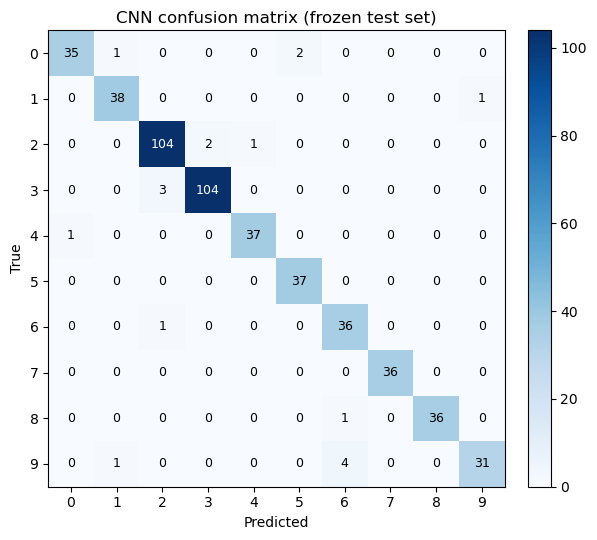

In [13]:
# Confusion matrix on the frozen test set
cm = confusion_matrix(y_test, y_test_hat, labels=list(range(CONFIG["N_CLASSES"])))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(CONFIG["N_CLASSES"])); ax.set_yticks(range(CONFIG["N_CLASSES"]))
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("CNN confusion matrix (frozen test set)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=9)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

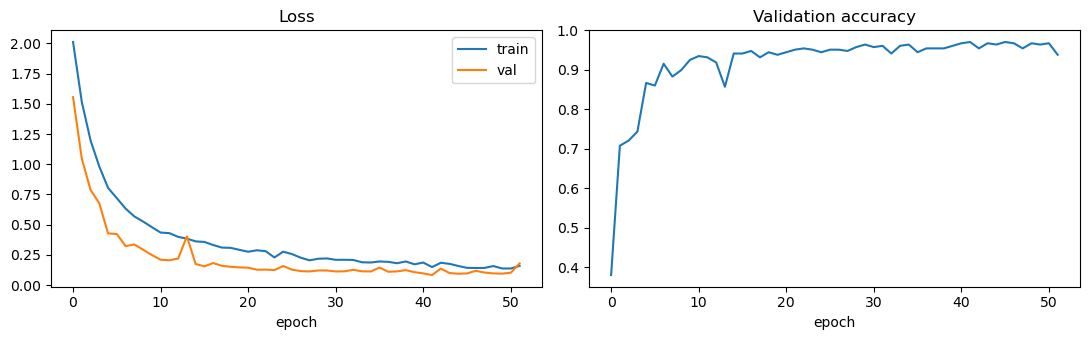

In [14]:
# Training curves for the final model (loss should converge smoothly, not jump to a perfect 100%)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(final_hist["train_loss"], label="train"); ax[0].plot(final_hist["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(final_hist["val_acc"]); ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 10. Classical baselines — the correct way

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Flatten images to 256-D pixel vectors
Xdev_flat = X_dev.reshape(len(X_dev), -1)
Xtest_flat = X_test.reshape(len(X_test), -1)

USE_PCA = True   # PCA is fit INSIDE each fold via the pipeline -> no leakage
def make_pipe(clf):
    steps = [("scale", StandardScaler())]
    if USE_PCA:
        steps.append(("pca", PCA(n_components=0.95, random_state=0)))  # keep 95% variance
    steps.append(("clf", clf))
    return Pipeline(steps)

classifiers = {
    "Naive Bayes":   GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=11, min_samples_leaf=3,
                                            min_samples_split=7, random_state=0),
    "SVM (RBF)":     SVC(C=10, gamma=0.01),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=0),
    "KNN":           KNeighborsClassifier(n_neighbors=3),
}

baseline_rows = []
for name, clf in classifiers.items():
    accs = []
    for seed in CONFIG["SEEDS"]:
        kf, is_group = make_kfold(groups_dev, CONFIG["N_FOLDS"], seed)
        cv = (kf.split(Xdev_flat, y_dev, groups_dev) if is_group
              else kf)
        scores = cross_val_score(make_pipe(clf), Xdev_flat, y_dev,
                                 cv=list(cv) if is_group else kf, scoring="accuracy",
                                 groups=groups_dev)
        accs.extend(scores.tolist())
    accs = np.array(accs)
    baseline_rows.append({"model": name,
                          "cv_acc_mean": accs.mean(),
                          "cv_acc_std": accs.std(ddof=1)})
    print(f"{name:15s}: {accs.mean()*100:6.2f}% +/- {accs.std(ddof=1)*100:.2f}")

baseline_df = pd.DataFrame(baseline_rows)
baseline_df

Naive Bayes    :  40.07% +/- 2.17
Decision Tree  :  54.90% +/- 1.79
SVM (RBF)      :  80.09% +/- 1.52
Random Forest  :  75.44% +/- 0.95
KNN            :  77.59% +/- 1.57


,model,cv_acc_mean,cv_acc_std
0,Naive Bayes,0.400718,0.021664
1,Decision Tree,0.548998,0.017853
2,SVM (RBF),0.800943,0.015197
3,Random Forest,0.754389,0.009543
4,KNN,0.775876,0.015728


In [16]:
# Final classical results on the frozen test set (fit on full dev set, evaluate once)
final_rows = []
for name, clf in classifiers.items():
    pipe = make_pipe(clf).fit(Xdev_flat, y_dev)
    yhat = pipe.predict(Xtest_flat)
    p, r, f1, _ = precision_recall_fscore_support(y_test, yhat, average="macro", zero_division=0)
    final_rows.append({"model": name, "test_accuracy": accuracy_score(y_test, yhat),
                       "test_macro_f1": f1})

final_rows.append({"model": "CNN",
                   "test_accuracy": accuracy_score(y_test, y_test_hat),
                   "test_macro_f1": precision_recall_fscore_support(
                       y_test, y_test_hat, average="macro", zero_division=0)[2]})
results_table = pd.DataFrame(final_rows).sort_values("test_accuracy", ascending=False)
print("Frozen test-set comparison (headline table for the paper):")
results_table.reset_index(drop=True)

Frozen test-set comparison (headline table for the paper):


,model,test_accuracy,test_macro_f1
0,CNN,0.964844,0.962045
1,SVM (RBF),0.808594,0.813492
2,KNN,0.791016,0.797087
3,Random Forest,0.765625,0.752610
4,Decision Tree,0.548828,0.523855
5,Naive Bayes,0.386719,0.400087


## 11. Standard-benchmark & cross-dataset evaluation (HODA)

In [17]:
HODA_DIR = r"C:\Users\c8472912\Desktop\D\paper\digits\final\paper\Hoda"

def load_hoda(hoda_dir, image_size):
    import sys, types
    sys.path.insert(0, hoda_dir)
    # Compatibility shim: the official reader uses np.int (removed in NumPy >= 1.24).
    if not hasattr(np, "int"):
        np.int = int
    from HodaDatasetReader import read_hoda_dataset
    def _load(cdb):
        X, Y = read_hoda_dataset(os.path.join(hoda_dir, "DigitDB", cdb),
                                 images_height=image_size, images_width=image_size,
                                 one_hot=False, reshape=False)   # -> (N,H,W,1) in {0,1}
        X = X.transpose(0, 3, 1, 2).astype(np.float32)           # -> (N,1,H,W)
        return X, Y.astype(np.int64)
    Xtr, ytr = _load("Train 60000.cdb")
    Xte, yte = _load("Test 20000.cdb")
    return Xtr, ytr, Xte, yte

def canonicalize(X, thresh=0.5, center=True, pad_frac=0.15):
    from PIL import Image
    Xc = X.copy().astype(np.float32)
    bright = Xc.reshape(len(Xc), -1).mean(axis=1) > 0.5
    Xc[bright] = 1.0 - Xc[bright]
    Xc = (Xc >= thresh).astype(np.float32)
    if not center:
        return Xc
    out = Xc.shape[-1]
    tgt = max(1, int(round(out * (1 - 2 * pad_frac))))   # digit fits within this box
    res = np.zeros_like(Xc)
    for i in range(len(Xc)):
        img = Xc[i, 0]
        ys, xs = np.where(img > 0)
        if len(xs) == 0:                 # empty image: leave blank
            continue
        crop = img[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
        h, w = crop.shape
        s = tgt / max(h, w)
        nh, nw = max(1, int(round(h * s))), max(1, int(round(w * s)))
        rz = np.asarray(Image.fromarray((crop * 255).astype(np.uint8)).resize((nw, nh)),
                        dtype=np.float32) / 255.0
        rz = (rz >= 0.5).astype(np.float32)
        oy, ox = (out - nh) // 2, (out - nw) // 2
        res[i, 0, oy:oy + nh, ox:ox + nw] = rz
    return res

try:
    Xh_tr, yh_tr, Xh_te, yh_te = load_hoda(HODA_DIR, CONFIG["IMAGE_SIZE"])
    print("HODA loaded:", Xh_tr.shape, Xh_te.shape)

    # (a) Within-HODA sanity check (should land near the ~99% in the literature)
    set_seed(CONFIG["SEEDS"][0])
    itr, iva = train_test_split(np.arange(len(yh_tr)), test_size=0.1,
                                stratify=yh_tr, random_state=CONFIG["SEEDS"][0])
    hoda_model, hoda_stats, _ = train_cnn(Xh_tr[itr], yh_tr[itr], Xh_tr[iva], yh_tr[iva],
                                          CONFIG, CONFIG["SEEDS"][0])
    print(f"[Within-HODA]  train HODA -> test HODA : "
          f"{accuracy_score(yh_te, predict_cnn(hoda_model, Xh_te, yh_te, hoda_stats))*100:.2f}%")

    #  Harmonise preprocessing, THEN cross-dataset (apples to apples) 
    print("\\nPreprocessing harmonisation (mean pixel = ink coverage):")
    print(f"  before      -> OURS {X_dev.mean():.2f} | HODA {Xh_tr.mean():.2f}  (opposite polarity = the bug)")
    Xours_dev_c, Xours_test_c = canonicalize(X_dev), canonicalize(X_test)
    Xh_tr_c,     Xh_te_c       = canonicalize(Xh_tr), canonicalize(Xh_te)
    print(f"  after center -> OURS {Xours_dev_c.mean():.2f} | HODA {Xh_tr_c.mean():.2f}  "
          f"(same polarity, and centring aligns ink coverage so any remaining gap is real style)")

    # train on canonical OURS -> test on canonical HODA
    set_seed(CONFIG["SEEDS"][0])
    vfrac = max(0.15, CONFIG["N_CLASSES"] / len(y_dev))
    tr, va = train_test_split(np.arange(len(y_dev)), test_size=vfrac,
                              stratify=y_dev, random_state=CONFIG["SEEDS"][0])
    m_ours, s_ours, _ = train_cnn(Xours_dev_c[tr], y_dev[tr], Xours_dev_c[va], y_dev[va],
                                  CONFIG, CONFIG["SEEDS"][0])
    acc_o2h = accuracy_score(yh_te, predict_cnn(m_ours, Xh_te_c, yh_te, s_ours))

    # train on canonical HODA -> test on canonical OURS (frozen test set)
    set_seed(CONFIG["SEEDS"][0])
    itr2, iva2 = train_test_split(np.arange(len(yh_tr)), test_size=0.1,
                                  stratify=yh_tr, random_state=CONFIG["SEEDS"][0])
    m_hoda, s_hoda, _ = train_cnn(Xh_tr_c[itr2], yh_tr[itr2], Xh_tr_c[iva2], yh_tr[iva2],
                                  CONFIG, CONFIG["SEEDS"][0])
    acc_h2o = accuracy_score(y_test, predict_cnn(m_hoda, Xours_test_c, y_test, s_hoda))

    print("\\n[Cross-dataset, preprocessing harmonised]")
    print(f"  train OURS -> test HODA : {acc_o2h*100:.2f}%")
    print(f"  train HODA -> test OURS : {acc_h2o*100:.2f}%")
    print("\\nWith identical preprocessing, any remaining gap is a genuine domain difference "
          "(writing styles, collection conditions), not an inverted-colour artifact. A moderate "
          "drop across independent datasets is normal; report these numbers, not the raw ones.")
except Exception as e:
    print("HODA step skipped:", repr(e))
    print("Set HODA_DIR correctly and `pip install opencv-python`, then re-run this cell.")

HODA loaded: (60000, 1, 16, 16) (20000, 1, 16, 16)
[Within-HODA]  train HODA -> test HODA : 99.08%
\nPreprocessing harmonisation (mean pixel = ink coverage):
  before      -> OURS 0.93 | HODA 0.24  (opposite polarity = the bug)
  after center -> OURS 0.11 | HODA 0.12  (same polarity, and centring aligns ink coverage so any remaining gap is real style)
\n[Cross-dataset, preprocessing harmonised]
  train OURS -> test HODA : 92.86%
  train HODA -> test OURS : 86.52%
\nWith identical preprocessing, any remaining gap is a genuine domain difference (writing styles, collection conditions), not an inverted-colour artifact. A moderate drop across independent datasets is normal; report these numbers, not the raw ones.


## 12. What to write in the paper

## 13. Save the trained model (for GitHub release)

In [18]:
import json, os
RELEASE_DIR = os.path.join(os.path.dirname(CONFIG["DATA_DIR"]), "PersianDigits_release")
os.makedirs(os.path.join(RELEASE_DIR, "model"), exist_ok=True)

# Weights of the final model (trained on the full dev set, evaluated once on the frozen test set)
torch.save(final_model.state_dict(), os.path.join(RELEASE_DIR, "model", "persian_digit_cnn.pt"))

meta = {
    "image_size": CONFIG["IMAGE_SIZE"],
    "n_classes": CONFIG["N_CLASSES"],
    "channels": 1,
    "preprocessing": "grayscale, resize to image_size, scale to [0,1], then standardize with norm_mean/std",
    "norm_mean": float(final_stats[0]),
    "norm_std": float(final_stats[1]),
    "dropout": CONFIG["DROPOUT"],
    "architecture": "DigitCNN: [Conv1->32,3x3,pad1,BN,ReLU,MaxPool2] [Conv2->64,3x3,pad1,BN,ReLU,MaxPool2] "
                    "[Flatten,Dropout,Linear->128,ReLU,Dropout,Linear->10]",
    "frozen_test_accuracy": float(accuracy_score(y_test, y_test_hat)),
    "cv_accuracy_mean": float(cv_df["accuracy"].mean()),
    "cv_accuracy_std": float(cv_df["accuracy"].std(ddof=1)),
    "labels": {str(i): str(i) for i in range(CONFIG["N_CLASSES"])},
}
with open(os.path.join(RELEASE_DIR, "model", "preprocessing.json"), "w") as f:
    json.dump(meta, f, indent=2)
print("Saved model weights + preprocessing.json to", os.path.join(RELEASE_DIR, "model"))
print(json.dumps(meta, indent=2))

Saved model weights + preprocessing.json to C:\Users\c8472912\Desktop\D\paper\digits\final\paper\PersianDigits_release\model
{
  "image_size": 16,
  "n_classes": 10,
  "channels": 1,
  "preprocessing": "grayscale, resize to image_size, scale to [0,1], then standardize with norm_mean/std",
  "norm_mean": 0.9258102774620056,
  "norm_std": 0.1992301046848297,
  "dropout": 0.3,
  "architecture": "DigitCNN: [Conv1->32,3x3,pad1,BN,ReLU,MaxPool2] [Conv2->64,3x3,pad1,BN,ReLU,MaxPool2] [Flatten,Dropout,Linear->128,ReLU,Dropout,Linear->10]",
  "frozen_test_accuracy": 0.96484375,
  "cv_accuracy_mean": 0.9710350448247757,
  "cv_accuracy_std": 0.00801335173841959,
  "labels": {
    "0": "0",
    "1": "1",
    "2": "2",
    "3": "3",
    "4": "4",
    "5": "5",
    "6": "6",
    "7": "7",
    "8": "8",
    "9": "9"
  }
}


## 14. Package the dataset (for GitHub release)


In [19]:
import csv
os.makedirs(RELEASE_DIR, exist_ok=True)

X_uint8 = (X[:, 0, :, :] * 255).round().astype(np.uint8)          # (N,H,W), lossless of the pixels
if groups is not None:
    writers_clean = np.array([("unknown" if str(w).startswith("__unknown_") else str(w))
                              for w in groups])
else:
    writers_clean = np.array(["unknown"] * len(y))

np.savez_compressed(os.path.join(RELEASE_DIR, "PersianDigits.npz"),
                    images=X_uint8, labels=y, writers=writers_clean,
                    image_size=np.int64(CONFIG["IMAGE_SIZE"]))

with open(os.path.join(RELEASE_DIR, "PersianDigits.csv"), "w", newline="") as f:
    wr = csv.writer(f)
    wr.writerow(["label", "writer"] + [f"px{i}" for i in range(CONFIG["IMAGE_SIZE"]**2)])
    flat = X_uint8.reshape(len(y), -1)
    for i in range(len(y)):
        wr.writerow([int(y[i]), writers_clean[i]] + flat[i].tolist())

print("Wrote PersianDigits.npz and PersianDigits.csv to", RELEASE_DIR)
print("images:", X_uint8.shape, "| labels:", y.shape)
print("writers:", dict(sorted(Counter(writers_clean.tolist()).items())))

Wrote PersianDigits.npz and PersianDigits.csv to C:\Users\c8472912\Desktop\D\paper\digits\final\paper\PersianDigits_release
images: (2560, 16, 16) | labels: (2560,)
writers: {'aila': 319, 'alireza': 300, 'dj': 310, 'm': 16, 'ma': 314, 'n': 300, 'reyhane': 300, 'sa': 299, 'unknown': 402}
